## MILESTONE 2


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [7]:
df = pd.read_csv("../data/processed/netflix_cleaned_featured.csv")

In [8]:
print(df.shape)
df.head()

(8807, 21)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,year_added,month_added,primary_country,genre_count,duration_num,content_length_category,content_age,release_decade,is_original
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",2021.0,9.0,United States,1,90.0,Medium Movie,1.0,2020,False
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",2021.0,9.0,South Africa,3,2.0,Multi Season,0.0,2020,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,2021.0,9.0,Unknown,3,1.0,Limited Series,0.0,2020,False
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,Unknown,2,1.0,Limited Series,0.0,2020,False
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,2021.0,9.0,India,3,2.0,Multi Season,0.0,2020,False


## Netflix Growth Over Time

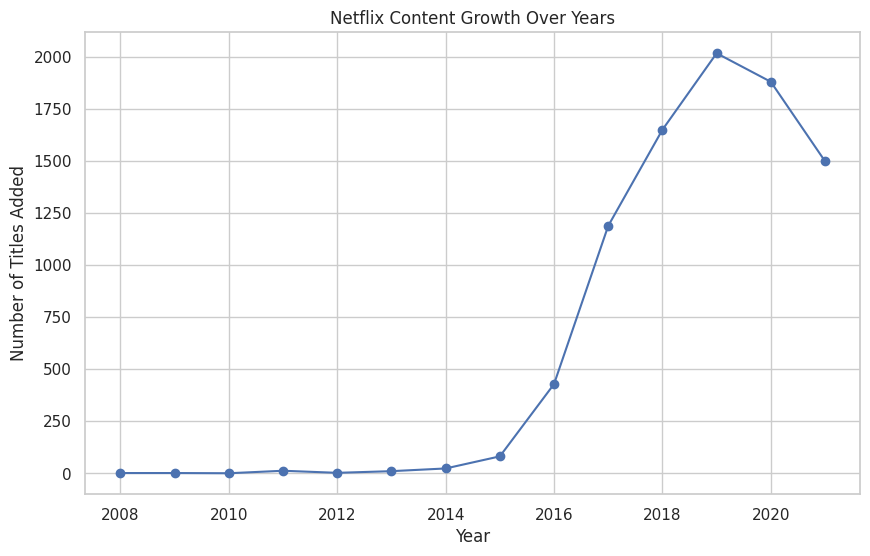

In [9]:
plt.figure(figsize=(10,6))
df.groupby('year_added').size().plot(kind='line', marker='o')
plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

## Content Type Distribution

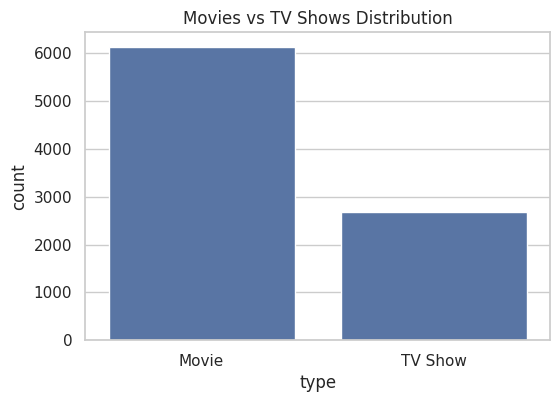

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows Distribution")
plt.show()

## Content Type Pie Chart

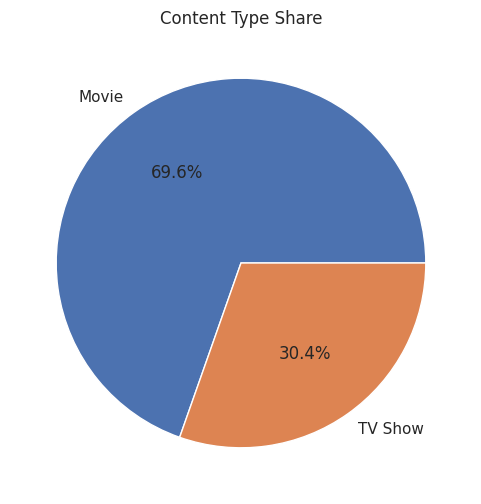

In [11]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title("Content Type Share")
plt.ylabel("")
plt.show()

## Top 10 Genres

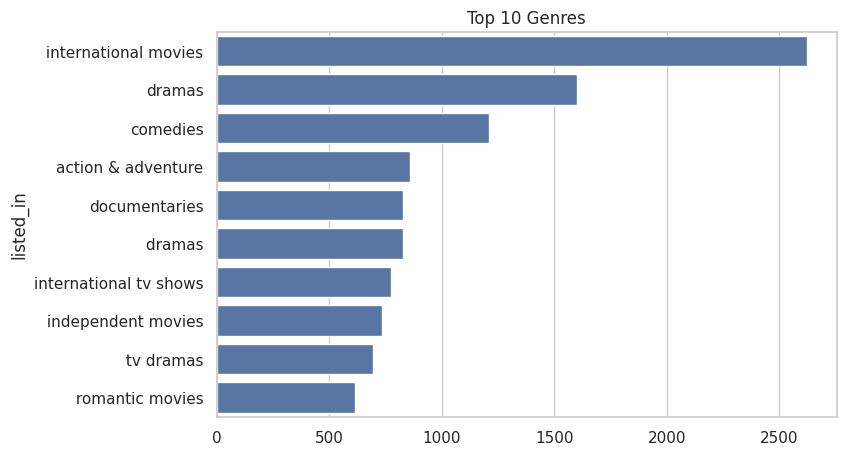

In [12]:
from collections import Counter

all_genres = df['listed_in'].str.split(',').explode()
top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()

## Top 10 Countries

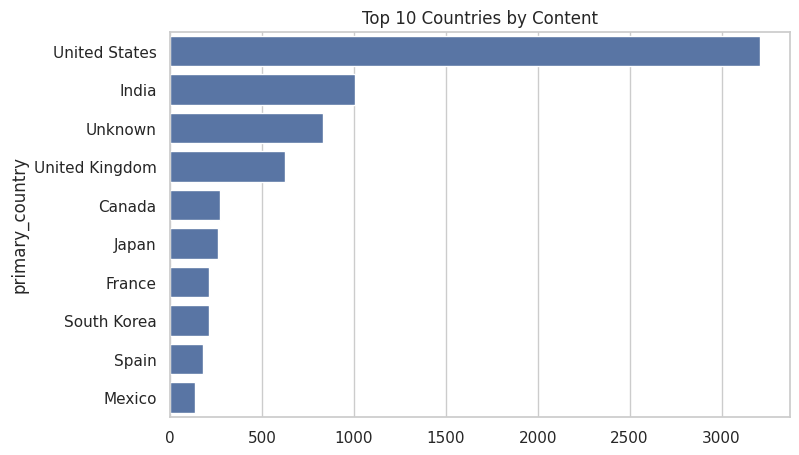

In [13]:
top_countries = df['primary_country'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Content")
plt.show()

## Rating Distribution (Histogram)

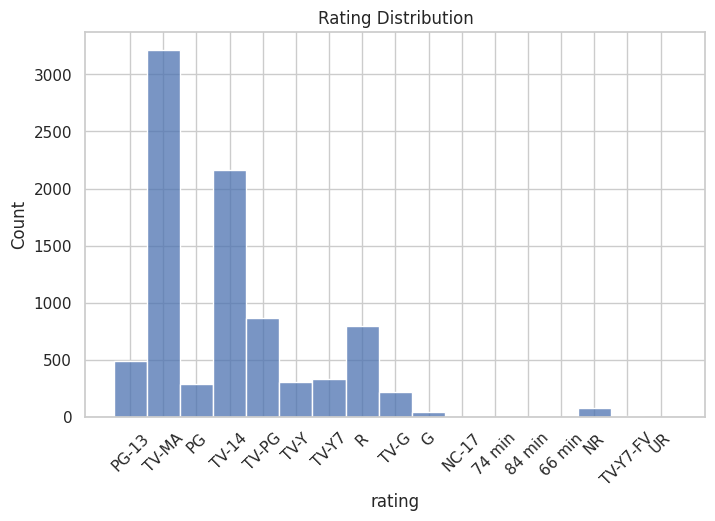

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=15)
plt.title("Rating Distribution")
plt.xticks(rotation=45)
plt.show()

## Duration Distribution

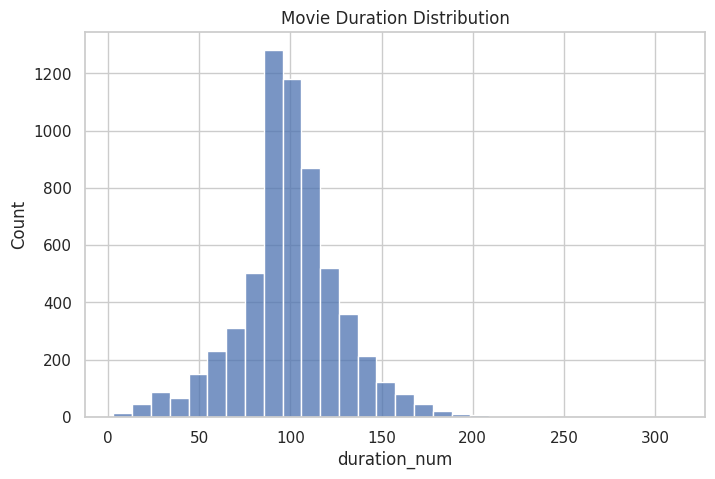

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['type']=="Movie"]['duration_num'], bins=30)
plt.title("Movie Duration Distribution")
plt.show()

## Content Age Distribution

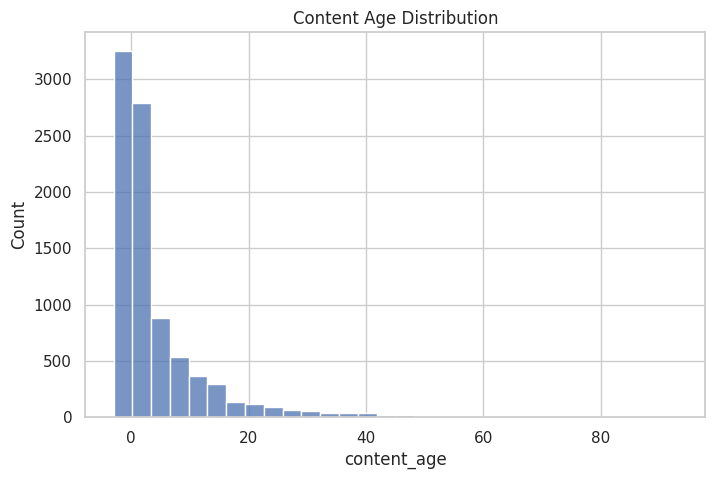

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['content_age'], bins=30)
plt.title("Content Age Distribution")
plt.show()

## Hypothesis Testing

### Hypothesis 1: Duration Difference (T-Test)

In [17]:
from scipy.stats import ttest_ind

movies = df[df['type']=="Movie"]['duration_num'].dropna()
shows = df[df['type']=="TV Show"]['duration_num'].dropna()

t_stat, p_value = ttest_ind(movies, shows)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 178.72436637716777
P-value: 0.0


In [18]:
from scipy.stats import ttest_ind

movies = df[df['type']=="Movie"]['duration_num'].dropna()
shows = df[df['type']=="TV Show"]['duration_num'].dropna()

t_stat, p_value = ttest_ind(movies, shows)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 178.72436637716777
P-value: 0.0


### Hypothesis 2: Country vs Original (Chi-Square)

In [19]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['primary_country'], df['is_original'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 6.971712785249803
P-value: 1.0


## Correlation Heatmap

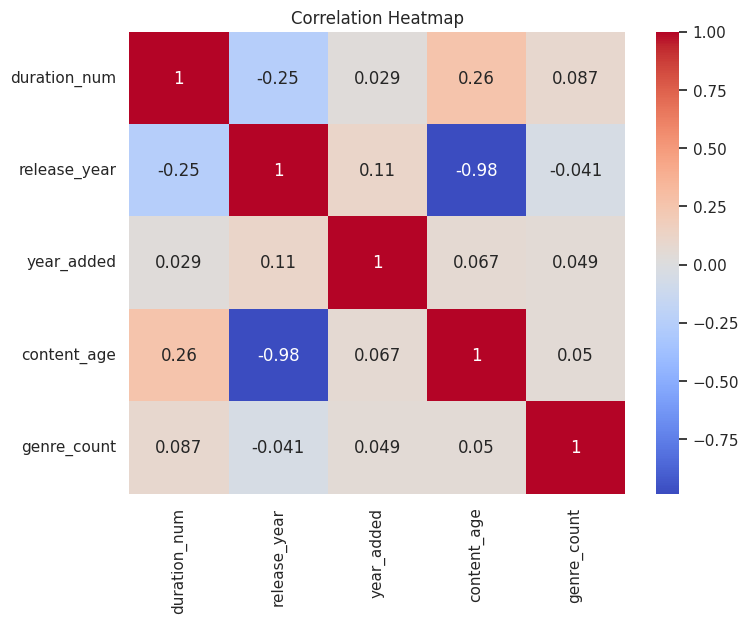

In [20]:
numeric_cols = ['duration_num', 'release_year', 'year_added', 'content_age', 'genre_count']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
import pandas as pd
df = pd.read_csv("../data/raw/netflix_titles.csv")

In [22]:
df.to_csv("../data/processed/netflix_feature_engineered.csv", index=False)